In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


RandomForest

Loading dataset...
Applying PCA...
Training Random Forest Classifier...
Evaluating model...
Accuracy: 0.91
Generating classification report...
              precision    recall  f1-score   support

     E-Waste       0.96      0.87      0.91       188
 Non-E-Waste       0.86      0.96      0.90       157

    accuracy                           0.91       345
   macro avg       0.91      0.91      0.91       345
weighted avg       0.91      0.91      0.91       345



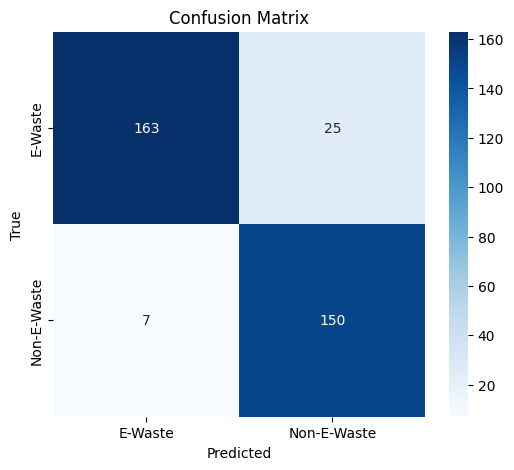

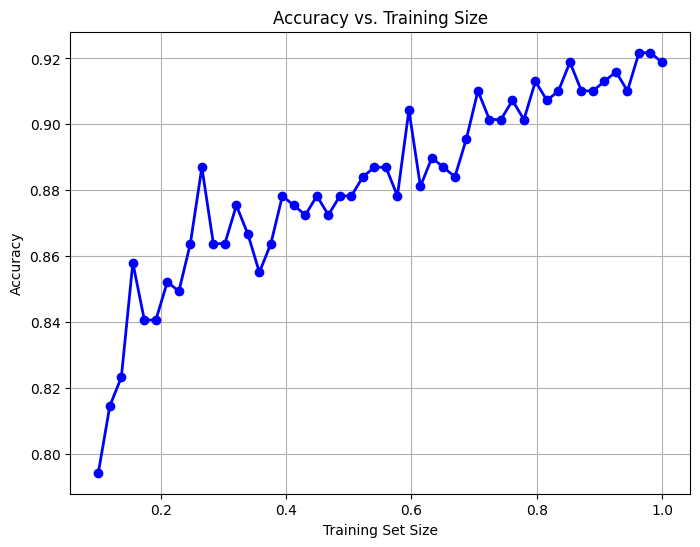

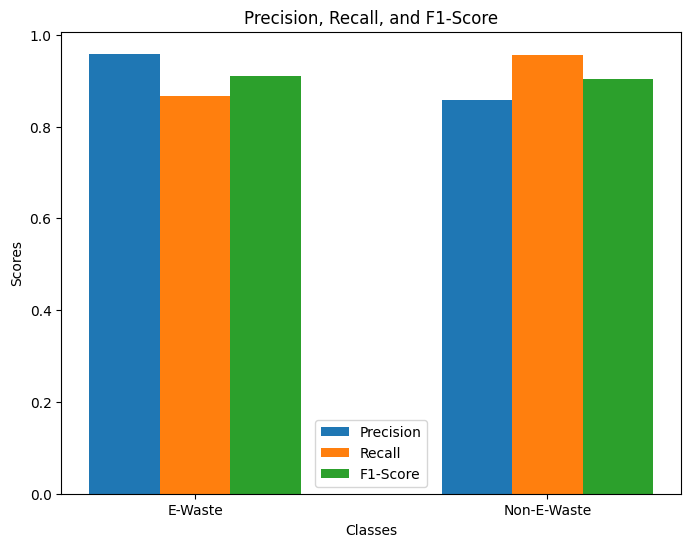

Model saved as e_waste_classifier.pkl
Starting real-time object detection...


In [10]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import pickle
import random

# Paths to datasets
data_dir = "/content/drive/MyDrive/Datasets/E-Waste_Dataset/modified-dataset/Dataset"
categories = ["E-Waste", "Non-E-Waste"]

# Feature extraction for both file paths and NumPy arrays
def extract_features(image_or_path):
    # Check if input is a file path or an image array
    if isinstance(image_or_path, str):  # If it's a file path
        image = cv2.imread(image_or_path)
    else:  # If it's a NumPy array (e.g., sliding window input)
        image = image_or_path

    if image is not None:
        image = cv2.resize(image, (64, 64))  # Resize to 64x64
        hist = cv2.calcHist([image], [0, 1, 2], None, [8, 8, 8], [0, 256, 0, 256, 0, 256])
        return cv2.normalize(hist, hist).flatten()  # Flatten to 1D
    return None

# Parallelized feature extraction
def load_dataset(data_dir, categories):
    filepaths = []
    labels = []
    for label, category in enumerate(categories):
        folder = os.path.join(data_dir, category)
        for filename in os.listdir(folder):
            filepaths.append(os.path.join(folder, filename))
            labels.append(label)

    # Parallel processing of features
    features = [extract_features(fp) for fp in filepaths]
    features, labels = zip(*[(f, l) for f, l in zip(features, labels) if f is not None])
    return np.array(features), np.array(labels)

print("Loading dataset...")
features, labels = load_dataset(data_dir, categories)

# Dimensionality Reduction with PCA
print("Applying PCA...")
pca = PCA(n_components=100)  # Reduce to 100 dimensions
features = pca.fit_transform(features)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

# Train Random Forest Classifier
print("Training Random Forest Classifier...")
clf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
clf.fit(X_train, y_train)

# Evaluate the model
print("Evaluating model...")
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Generate additional metrics
print("Generating classification report...")
report = classification_report(y_test, y_pred, target_names=categories)
print(report)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plotting the Accuracy vs. Training Size
train_sizes = np.linspace(0.1, 0.9999999)  # Now it's a fraction (not an absolute number)
train_accuracies = []

for size in train_sizes:
    X_train_subset, _, y_train_subset, _ = train_test_split(X_train, y_train, train_size=size, random_state=42)
    clf.fit(X_train_subset, y_train_subset)
    y_train_pred = clf.predict(X_test)
    train_accuracies.append(accuracy_score(y_test, y_train_pred))

# Plotting Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=categories, yticklabels=categories)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Plotting Accuracy vs Training Size
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_accuracies, marker='o', color='b', linestyle='-', linewidth=2)
plt.title("Accuracy vs. Training Size")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

# Plotting Precision, Recall, and F1-Score
metrics = classification_report(y_test, y_pred, output_dict=True)

# Corrected to access metrics using integer labels
precision = [metrics[str(label)]["precision"] for label in range(len(categories))]
recall = [metrics[str(label)]["recall"] for label in range(len(categories))]
f1_score = [metrics[str(label)]["f1-score"] for label in range(len(categories))]

plt.figure(figsize=(8, 6))
x = np.arange(len(categories))
width = 0.2

plt.bar(x - width, precision, width, label="Precision")
plt.bar(x, recall, width, label="Recall")
plt.bar(x + width, f1_score, width, label="F1-Score")

plt.xlabel("Classes")
plt.ylabel("Scores")
plt.title("Precision, Recall, and F1-Score")
plt.xticks(x, categories)
plt.legend()
plt.show()

# Save the trained model and PCA object
with open("e_waste_classifier.pkl", "wb") as f:
    pickle.dump({"model": clf, "pca": pca, "categories": categories}, f)
print("Model saved as e_waste_classifier.pkl")

# Real-Time Object Detection with Max 3 Bounding Boxes
print("Starting real-time object detection...")
cap = cv2.VideoCapture(0)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    height, width, _ = frame.shape
    step_size = 50
    window_size = (100, 100)

    # Track the number of boxes drawn
    boxes_drawn = 0
    detections = []  # List to track detected objects and their confidence

    # Convert frame to grayscale for contour detection
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

    # Find contours (which will correspond to objects in the image)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    for contour in contours:
        # Only consider contours that are large enough to be considered objects
        if cv2.contourArea(contour) < 500:  # Minimum area for detection
            continue

        # Get the bounding box for each contour
        x, y, w, h = cv2.boundingRect(contour)
        window = frame[y:y + h, x:x + w]

        # Extract features from the window
        features = extract_features(window)
        if features is not None:
            features = pca.transform([features])  # Apply PCA
            prediction = clf.predict(features)
            confidence = np.max(clf.predict_proba(features))  # Get the confidence (probability)
            label = categories[prediction[0]]

            # Only draw box if the confidence is above a certain threshold
            if confidence > 0.8:  # Adjust confidence threshold if necessary
                detections.append((x, y, label, confidence))

                # Draw bounding box and label with confidence
                color = (0, 255, 0) if label == "E-Waste" else (0, 0, 255)
                cv2.rectangle(frame, (x, y), (x + w, y + h), color, 2)
                cv2.putText(frame, f"{label} ({confidence:.2f})", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

                boxes_drawn += 1  # Increment count of boxes drawn

        if boxes_drawn >= 3:
            break  # Exit the loop if 3 boxes are already drawn

    # Display the result
    cv2.imshow("Real-Time Detection", frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()


SVM

Loading dataset...
Applying PCA...
Training SVM Classifier...
Evaluating model...
Accuracy: 0.86


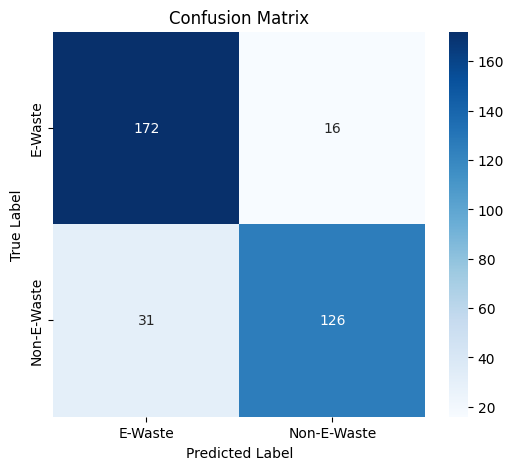

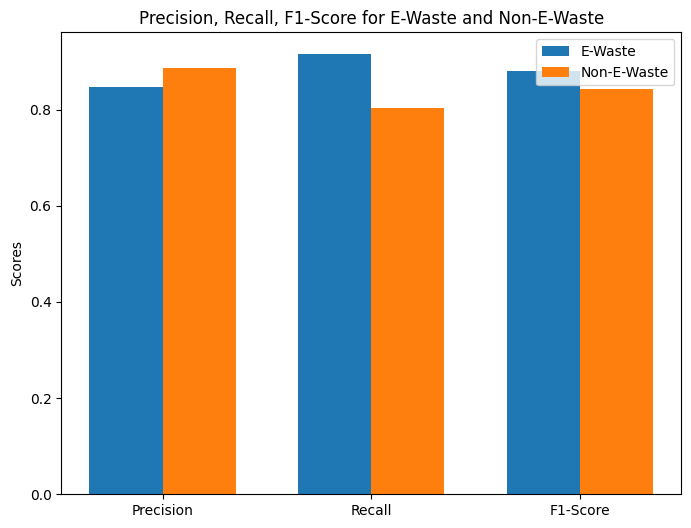

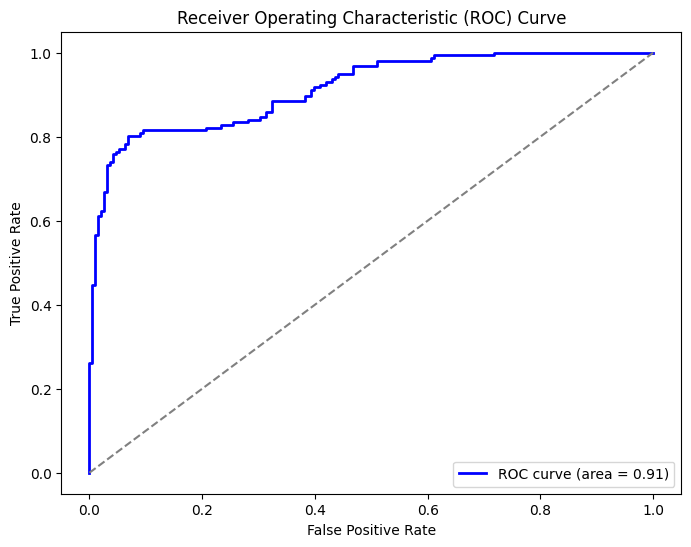

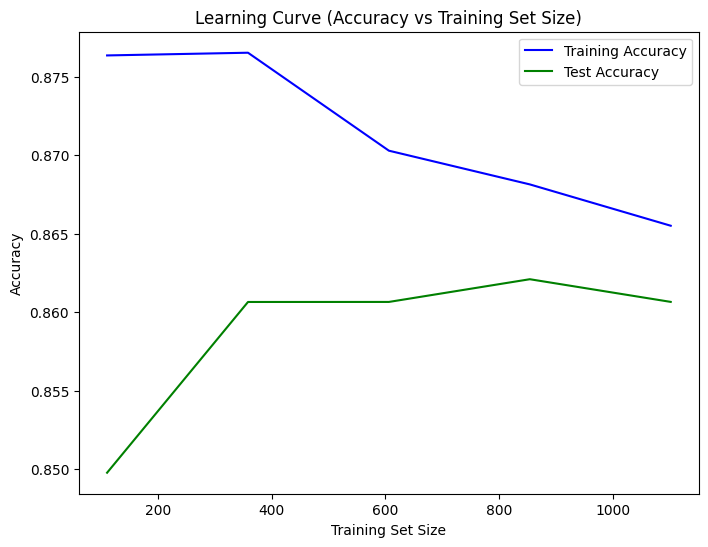

Model saved as e_waste_classifier_svm.pkl
Starting real-time object detection...


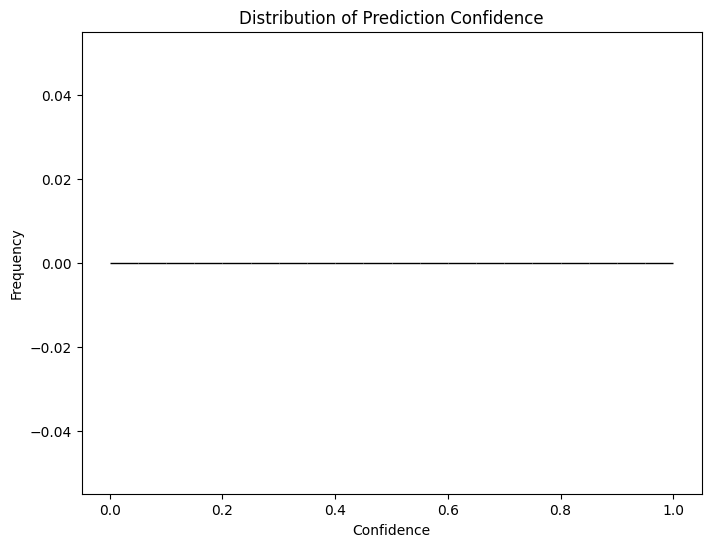

In [11]:
import os
import cv2
import numpy as np
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split, learning_curve
import pickle
import random
import matplotlib.pyplot as plt
import seaborn as sns

# Paths to datasets
data_dir = "/content/drive/MyDrive/Datasets/E-Waste_Dataset/modified-dataset/Dataset"
categories = ["E-Waste", "Non-E-Waste"]

# Feature extraction for both file paths and NumPy arrays
def extract_features(image_or_path):
    if isinstance(image_or_path, str):  # If it's a file path
        image = cv2.imread(image_or_path)
    else:  # If it's a NumPy array (e.g., sliding window input)
        image = image_or_path

    if image is not None:
        image = cv2.resize(image, (64, 64))  # Resize to 64x64
        hist = cv2.calcHist([image], [0, 1, 2], None, [8, 8, 8], [0, 256, 0, 256, 0, 256])
        return cv2.normalize(hist, hist).flatten()  # Flatten to 1D
    return None

# Parallelized feature extraction
def load_dataset(data_dir, categories):
    filepaths = []
    labels = []
    for label, category in enumerate(categories):
        folder = os.path.join(data_dir, category)
        for filename in os.listdir(folder):
            filepaths.append(os.path.join(folder, filename))
            labels.append(label)

    # Parallel processing of features
    features = [extract_features(fp) for fp in filepaths]
    features, labels = zip(*[(f, l) for f, l in zip(features, labels) if f is not None])
    return np.array(features), np.array(labels)

print("Loading dataset...")
features, labels = load_dataset(data_dir, categories)

# Dimensionality Reduction with PCA
print("Applying PCA...")
pca = PCA(n_components=100)  # Reduce to 100 dimensions
features = pca.fit_transform(features)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

# Train SVM Classifier
print("Training SVM Classifier...")
clf = SVC(kernel='linear', probability=True, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)

# Evaluate the model
print("Evaluating model...")
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Precision, Recall, F1-Score
precision = precision_score(y_test, y_pred, average=None)
recall = recall_score(y_test, y_pred, average=None)
f1 = f1_score(y_test, y_pred, average=None)

metrics = ['Precision', 'Recall', 'F1-Score']
e_waste_metrics = [precision[0], recall[0], f1[0]]
non_e_waste_metrics = [precision[1], recall[1], f1[1]]

x = np.arange(len(metrics))  # label locations
width = 0.35  # bar width

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(x - width/2, e_waste_metrics, width, label='E-Waste')
ax.bar(x + width/2, non_e_waste_metrics, width, label='Non-E-Waste')

ax.set_ylabel('Scores')
ax.set_title('Precision, Recall, F1-Score for E-Waste and Non-E-Waste')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, clf.predict_proba(X_test)[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# Learning Curves
train_sizes, train_scores, test_scores = learning_curve(clf, X_train, y_train, cv=5)
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label="Training Accuracy", color='blue')
plt.plot(train_sizes, test_mean, label="Test Accuracy", color='green')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve (Accuracy vs Training Set Size)')
plt.legend()
plt.show()

# Save the trained model and PCA object
with open("e_waste_classifier_svm.pkl", "wb") as f:
    pickle.dump({"model": clf, "pca": pca, "categories": categories}, f)
print("Model saved as e_waste_classifier_svm.pkl")

# Real-Time Object Detection with Max 3 Bounding Boxes
print("Starting real-time object detection...")
cap = cv2.VideoCapture(0)
detections = []  # List to track detected objects and their confidence

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    height, width, _ = frame.shape
    step_size = 50
    window_size = (100, 100)

    # Track the number of boxes drawn
    boxes_drawn = 0
    detections = []  # List to track detected objects and their confidence

    # Convert frame to grayscale for contour detection
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

    # Find contours (which will correspond to objects in the image)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    for contour in contours:
        # Only consider contours that are large enough to be considered objects
        if cv2.contourArea(contour) < 200:  # Lowering the threshold for contour area
            continue

        # Get the bounding box for each contour
        x, y, w, h = cv2.boundingRect(contour)
        window = frame[y:y + h, x:x + w]

        # Extract features from the window
        features = extract_features(window)
        if features is not None:
            features = pca.transform([features])  # Apply PCA
            prediction = clf.predict(features)
            confidence = np.max(clf.predict_proba(features))  # Get the confidence (probability)
            label = categories[prediction[0]]

            # Only draw box if the confidence is above a certain threshold
            if confidence > 0.8:  # Adjust confidence threshold if necessary
                detections.append((x, y, label, confidence))

                # Draw bounding box and label with confidence
                color = (0, 255, 0) if label == "E-Waste" else (0, 0, 255)
                cv2.rectangle(frame, (x, y), (x + w, y + h), color, 2)
                cv2.putText(frame, f"{label} ({confidence:.2f})", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

                boxes_drawn += 1  # Increment count of boxes drawn

        if boxes_drawn >= 3:
            break  # Exit the loop if 3 boxes are already drawn

    # Display the result
    cv2.imshow("Real-Time Detection", frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

# Prediction Confidence Histogram
confidences = [d[3] for d in detections]
plt.figure(figsize=(8, 6))
plt.hist(confidences, bins=20, color='orange', edgecolor='black')
plt.title("Distribution of Prediction Confidence")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.show()


XGBoost

Loading dataset...
Applying PCA...
Training XGBoost Classifier...
Evaluating model...
Accuracy: 0.95
Model saved as e_waste_classifier_xgboost.pkl


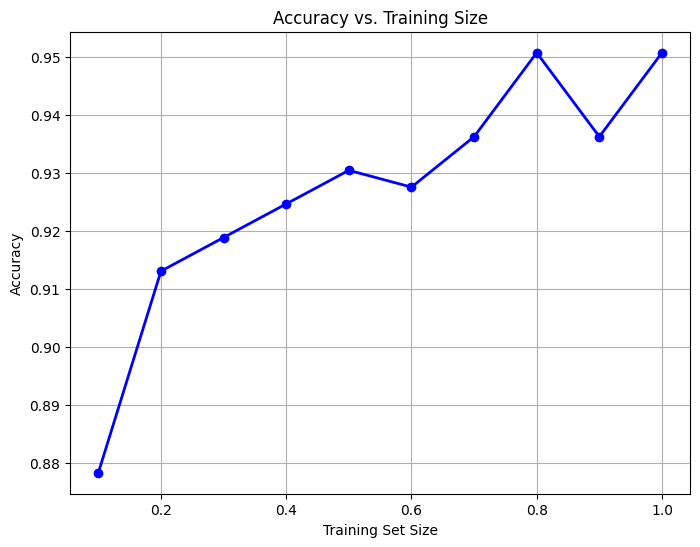

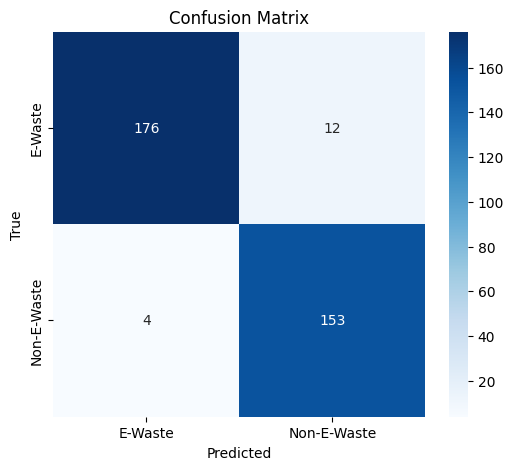

Metrics keys:  dict_keys(['0', '1', 'accuracy', 'macro avg', 'weighted avg'])


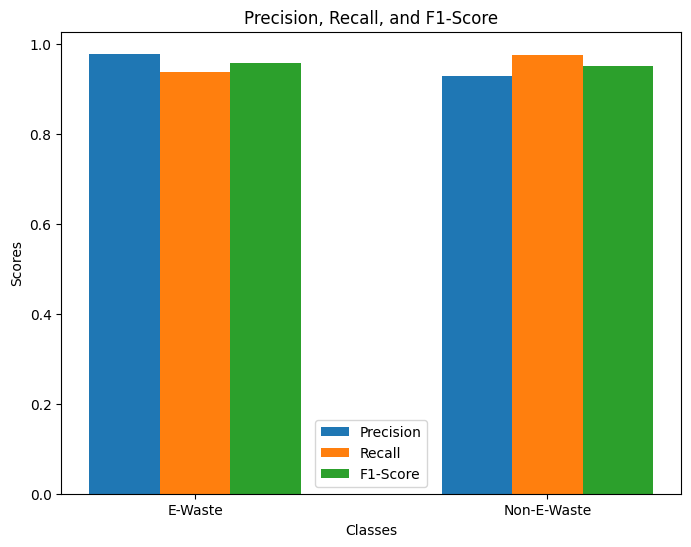

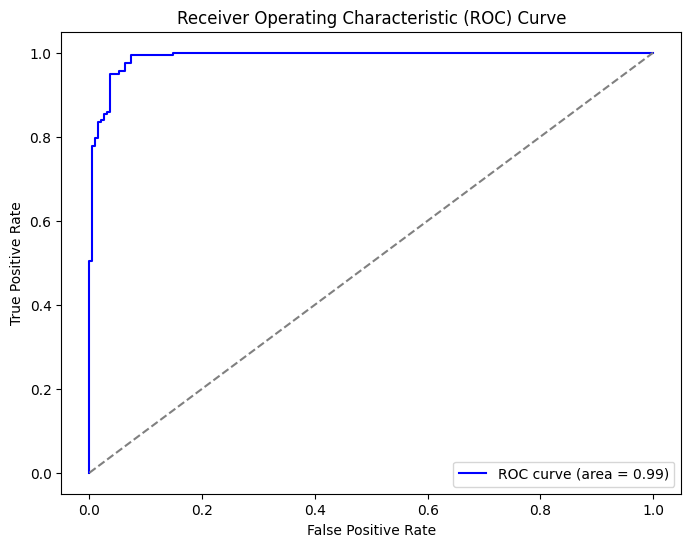

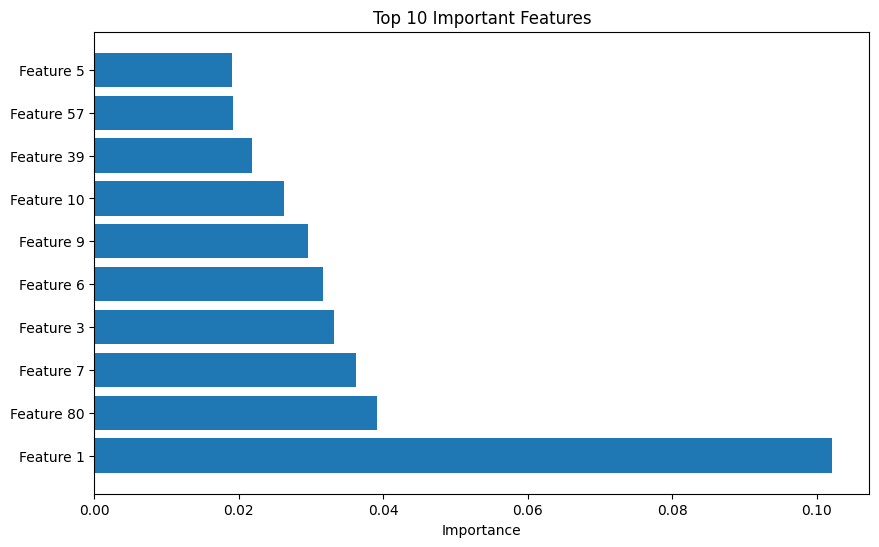

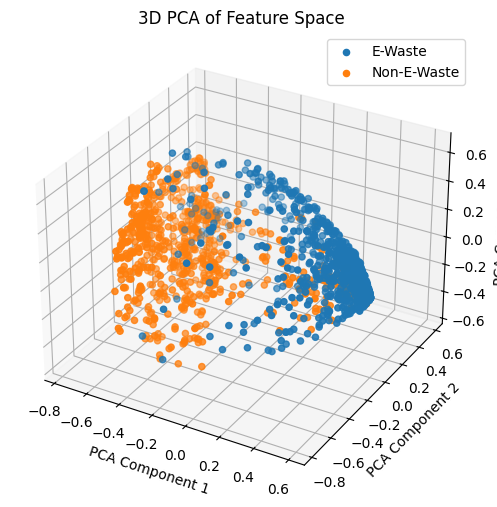

Starting real-time object detection...


In [12]:
import os
import cv2
import numpy as np
import xgboost as xgb
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import pickle
import random
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Paths to datasets
data_dir = "/content/drive/MyDrive/Datasets/E-Waste_Dataset/modified-dataset/Dataset"
categories = ["E-Waste", "Non-E-Waste"]

# Feature extraction for both file paths and NumPy arrays
def extract_features(image_or_path):
    # Check if input is a file path or an image array
    if isinstance(image_or_path, str):  # If it's a file path
        image = cv2.imread(image_or_path)
    else:  # If it's a NumPy array (e.g., sliding window input)
        image = image_or_path

    if image is not None:
        image = cv2.resize(image, (64, 64))  # Resize to 64x64
        hist = cv2.calcHist([image], [0, 1, 2], None, [8, 8, 8], [0, 256, 0, 256, 0, 256])
        return cv2.normalize(hist, hist).flatten()  # Flatten to 1D
    return None

# Parallelized feature extraction
def load_dataset(data_dir, categories):
    filepaths = []
    labels = []
    for label, category in enumerate(categories):
        folder = os.path.join(data_dir, category)
        for filename in os.listdir(folder):
            filepaths.append(os.path.join(folder, filename))
            labels.append(label)

    # Parallel processing of features
    features = [extract_features(fp) for fp in filepaths]
    features, labels = zip(*[(f, l) for f, l in zip(features, labels) if f is not None])
    return np.array(features), np.array(labels)

print("Loading dataset...")
features, labels = load_dataset(data_dir, categories)

# Dimensionality Reduction with PCA
print("Applying PCA...")
pca = PCA(n_components=100)  # Reduce to 100 dimensions
features = pca.fit_transform(features)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

# Train XGBoost Classifier
print("Training XGBoost Classifier...")
clf = xgb.XGBClassifier(eval_metric='mlogloss', random_state=42, scale_pos_weight=1)
clf.fit(X_train, y_train)

# Evaluate the model
print("Evaluating model...")
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Save the trained model and PCA object
with open("e_waste_classifier_xgboost.pkl", "wb") as f:
    pickle.dump({"model": clf, "pca": pca, "categories": categories}, f)
print("Model saved as e_waste_classifier_xgboost.pkl")

# Plotting Model Accuracy vs. Training Size Curve
train_sizes = np.linspace(0.1, 0.99999, 10)  # Fraction of training data
train_accuracies = []

for size in train_sizes:
    X_train_subset, _, y_train_subset, _ = train_test_split(X_train, y_train, train_size=size, random_state=42)
    clf.fit(X_train_subset, y_train_subset)
    y_train_pred = clf.predict(X_test)
    train_accuracies.append(accuracy_score(y_test, y_train_pred))

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_accuracies, marker='o', color='b', linestyle='-', linewidth=2)
plt.title("Accuracy vs. Training Size")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

# Plotting Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=categories, yticklabels=categories)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Plotting Precision, Recall, F1-Score Comparison
metrics = classification_report(y_test, y_pred, output_dict=True)
print("Metrics keys: ", metrics.keys())

# Ensure correct access of metrics by handling both '0' and '1' categories
precision = [metrics[str(i)]["precision"] for i in range(len(categories))]
recall = [metrics[str(i)]["recall"] for i in range(len(categories))]
f1_score = [metrics[str(i)]["f1-score"] for i in range(len(categories))]

plt.figure(figsize=(8, 6))
x = np.arange(len(categories))
width = 0.2

plt.bar(x - width, precision, width, label="Precision")
plt.bar(x, recall, width, label="Recall")
plt.bar(x + width, f1_score, width, label="F1-Score")

plt.xlabel("Classes")
plt.ylabel("Scores")
plt.title("Precision, Recall, and F1-Score")
plt.xticks(x, categories)
plt.legend()
plt.show()

# Plotting ROC Curve & AUC Score
y_test_bin = label_binarize(y_test, classes=[0, 1])
y_pred_prob = clf.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test_bin, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

# Plotting Feature Importance Visualization
importance = clf.feature_importances_

# Sort feature importance
indices = np.argsort(importance)[::-1]

# Plot the top 10 most important features
plt.figure(figsize=(10, 6))
plt.barh(range(10), importance[indices][:10], align='center')
plt.yticks(range(10), [f"Feature {i+1}" for i in indices[:10]])  # Feature labels
plt.xlabel('Importance')
plt.title('Top 10 Important Features')
plt.show()

# Plotting 3D Feature Visualization
pca_3d = PCA(n_components=3)
features_3d = pca_3d.fit_transform(features)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot points for each class
for i, category in enumerate(categories):
    ax.scatter(features_3d[labels == i, 0], features_3d[labels == i, 1], features_3d[labels == i, 2], label=category)

ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
plt.title("3D PCA of Feature Space")
plt.legend()
plt.show()

# Real-Time Object Detection with Bounding Boxes
print("Starting real-time object detection...")
cap = cv2.VideoCapture(0)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    height, width, _ = frame.shape
    step_size = 50
    window_size = (100, 100)

    # Track the number of boxes drawn
    boxes_drawn = 0
    detections = []  # List to track detected objects and their confidence

    # Convert frame to grayscale for contour detection
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

    # Find contours (which will correspond to objects in the image)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    for contour in contours:
        # Only consider contours that are large enough to be considered objects
        if cv2.contourArea(contour) < 200:  # Lowering the threshold for contour area
            continue

        # Get the bounding box for each contour
        x, y, w, h = cv2.boundingRect(contour)
        window = frame[y:y + h, x:x + w]

        # Extract features from the window
        features = extract_features(window)
        if features is not None:
            features = pca.transform([features])  # Apply PCA
            prediction = clf.predict(features)
            confidence = clf.predict_proba(features)  # Get the confidence (probability)
            confidence = np.max(confidence)  # Take the highest probability
            label = categories[prediction[0]]

            # Only draw box if the confidence is above a threshold
            if confidence > 0.75:
                cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
                cv2.putText(frame, f"{label} {confidence:.2f}", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

                boxes_drawn += 1
                detections.append((label, confidence))

    print(f"Detected {boxes_drawn} objects.")

    cv2.imshow("Real-Time Detection", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
